#Système d'Affectation de Patients aux Hôpitaux
## Modèle de Machine Learning — Logistic Regression

Ce notebook implémente un modèle de **régression logistique** pour recommander automatiquement le meilleur hôpital à un patient, en fonction de :
- La **disponibilité des ressources** médicales de chaque hôpital (lits, médecins, équipements...)
- La **gravité du patient** (score ESI de 1 à 5)
- La **distance géographique** entre le patient et chaque hôpital

### Données requises
| Fichier | Description |
|---|---|
| `patients_1000_ULTRA_COMPLET.xlsx` | 1 000 dossiers patients avec besoins en ressources |
| `Book1.xlsx` | Liste de 21 hôpitaux avec leurs capacités |

### Architecture du pipeline
```
Données brutes → Feature Engineering → Dataset (21 000 paires) → Logistic Regression → Affectation
```

---
## Bloc 1 — Imports et Configuration

**Objectif :** Charger toutes les bibliothèques nécessaires et définir les constantes globales du projet.

- `pandas` / `numpy` : manipulation des données
- `scikit-learn` : modèle ML, métriques, pipeline
- `joblib` : sauvegarde/chargement du modèle entraîné
- `RESOURCE_MAPPINGS` : dictionnaire de correspondance entre les colonnes du fichier patients et les colonnes du fichier hôpitaux — c'est la "clé de traduction" entre les deux sources de données

In [28]:
import sys
import pandas as pd
import numpy as np
# Visualisations
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, average_precision_score
)
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques chargées avec succès")

Bibliothèques chargées avec succès


In [29]:
PATIENTS_PATH  = 'patients_1000_ULTRA_COMPLET.xlsx'
HOSPITALS_PATH = 'Book1.xlsx'
MODEL_PATH     = 'patient_assignment_model.pkl'
OUTPUT_PATH    = 'resultats_affectation.xlsx'

# Correspondances colonnes patient ↔ colonnes hôpital
# Format : 'Ressource' -> {'p': colonne_dans_patients, 'h': colonne_dans_hopitaux}
RESOURCE_MAPPINGS = {
    'Lit':            {'p': 'Lits_totaux',    'h': 'Lits totaux'},
    'Rea_Lit':        {'p': 'Rea_lits',        'h': 'Réa (lits)'},
    'Medecin':        {'p': 'Medecins',         'h': 'Médecins'},
    'Infirmier':      {'p': 'Infirmiers',        'h': 'Infirmiers'},
    'Urgentiste':     {'p': 'Urgentistes',       'h': 'Urgentistes'},
    'Reanimateur':    {'p': 'Reanimateurs',      'h': 'Réanimateurs'},
    'Anesth_Rea':     {'p': 'Anesth_Rea',        'h': 'Anesth.-Réa'},
    'Pneumo':         {'p': 'Pneumo',            'h': 'Pneumo'},
    'Cardio':         {'p': 'Cardio',            'h': 'Cardio'},
    'Neuro':          {'p': 'Neuro',             'h': 'Neuro'},
    'Interniste':     {'p': 'Internistes',        'h': 'Internistes'},
    'Chirurgien':     {'p': 'Chirurgiens',        'h': 'Chirurgiens'},
    'Pediatre':       {'p': 'Pediatres',          'h': 'Pédiatres'},
    'Biologiste':     {'p': 'Biologistes',         'h': 'Biologistes'},
    'Radiologue':     {'p': 'Radiologues',         'h': 'Radiologues'},
    'O2':             {'p': 'O2',                 'h': 'O\u2082'},
    'Ventilateur':    {'p': 'Ventilateur',         'h': 'Ventilateurs'},
    'Sang':           {'p': 'Sang',               'h': 'Sang (unités)'},
    'Moniteur':       {'p': 'Moniteurs',           'h': 'Moniteurs'},
    'Defibrillateur': {'p': 'Defibrillateur',      'h': 'Défibrillateurs'},
    'Monitoring':     {'p': 'Monitoring',          'h': 'Moniteurs'},
    'Labo':           {'p': 'Labo',               'h': 'Labo'},
    'Imagerie':       {'p': 'Imagerie',            'h': 'Imagerie'},
}

# Poids du scoring heuristique (pour générer les labels)
COVERAGE_WEIGHT = 0.7   # priorité à la couverture des ressources médicales
DISTANCE_WEIGHT = 0.3   #  proximité géographique
DISTANCE_NORM   = 50.0  # Distance de normalisation en km

print(f"Configuration chargée — {len(RESOURCE_MAPPINGS)} ressources mappées")

Configuration chargée — 23 ressources mappées


---
## Bloc 2 — Chargement et Nettoyage des Données

**Objectif :** Lire les deux fichiers Excel et nettoyer les données avant tout traitement.

**Problème spécifique :** Le fichier `Book1.xlsx` contient une ligne de légende en bas du tableau (dans la colonne `Réanimateurs`), qui est un long texte descriptif. On la détecte et la supprime avant d'utiliser les données.

In [ ]:
def load_data(patients_path="C:/Users/HP/OneDrive/Desktop/silma/logistic_regression/patients_1000_ULTRA_COMPLET.xlsx", hospitals_path="C:/Users/HP/OneDrive/Desktop/silma/logistic_regression/Book1.xlsx"):
    
    patients = pd.read_excel(patients_path)

    hospitals = pd.read_excel(hospitals_path)
    hospitals.columns = [c.strip() for c in hospitals.columns] 

    # Suppression de la ligne de légende (texte > 30 caractères dans 'Réanimateurs')
    hospitals = hospitals[
        hospitals['Réanimateurs'].apply(
            lambda x: isinstance(x, (int, float)) or
                      (isinstance(x, str) and len(str(x)) < 30)
        )
    ].copy()

    # Forcer le type numérique sur la colonne Réanimateurs (était 'object')
    hospitals['Réanimateurs'] = pd.to_numeric(hospitals['Réanimateurs'], errors='coerce')
    hospitals = hospitals.fillna(0).reset_index(drop=True)

    return patients, hospitals


patients, hospitals = load_data()

print(f"Patients  : {len(patients)} lignes x {len(patients.columns)} colonnes")
print(f"Hôpitaux  : {len(hospitals)} lignes x {len(hospitals.columns)} colonnes")
print(f"\nAperçu patients :")
display(patients[['ID', 'ESI', 'Service', 'Latitude', 'Longitude', 'Lits_totaux', 'Rea_lits']].head())

Patients  : 1000 lignes x 36 colonnes
Hôpitaux  : 21 lignes x 26 colonnes

Aperçu patients :


,ID,ESI,Service,Latitude,Longitude,Lits_totaux,Rea_lits
0,1,4,Médecine,12.362048,-1.512755,0,0
1,2,5,Suivi,12.390064,-1.454999,0,0
2,3,5,Suivi,12.420065,-1.559298,0,0
3,4,5,Suivi,12.416068,-1.456410,0,0
4,5,2,Pneumo,12.317364,-1.541741,1,0


In [31]:
print("Distribution des niveaux de gravité ESI")
print(patients['ESI'].value_counts().sort_index().to_string())

print("\nTop 10 services")
print(patients['Service'].value_counts().head(10).to_string())

print("\nAperçu des hôpitaux")
display(hospitals[['Hôpital', 'Lits totaux', 'Réa (lits)', 'Médecins', 'Urgentistes']].head(10))

Distribution des niveaux de gravité ESI
ESI
1    102
2    150
3    324
4    231
5    193

Top 10 services
Service
Médecine        219
Suivi           193
Consultation    120
Neuro           112
Chirurgie       104
Gynéco           59
Cardio           49
Réanimation      43
Pneumo           42
Trauma           30

Aperçu des hôpitaux


,Hôpital,Lits totaux,Réa (lits),Médecins,Urgentistes
0,Centre Hospitalier Universitaire Yalgado Ouédr...,800.0,20.0,120.0,25.0
1,Centre Hospitalier Universitaire de Tingandogo,600.0,15.0,100.0,20.0
2,Centre Hospitalier Universitaire de Bogodogo,500.0,8.0,90.0,18.0
3,CHU Pédiatrique Charles de Gaulle,400.0,12.0,80.0,15.0
4,Hôpital Paul VI,250.0,5.0,60.0,10.0
5,Hôpital Saint Camille,300.0,5.0,65.0,10.0
6,Centre Médical Protestant Schiphra,200.0,2.0,50.0,8.0
7,Polyclinique Internationale de Ouagadougou,220.0,4.0,55.0,9.0
8,Clinique Princesse Sarah,150.0,1.0,30.0,5.0
9,Centre Médical Ahmadiyya,120.0,0.0,25.0,4.0


---
## Bloc 3 — Feature Engineering

**Objectif :** Construire le vecteur de caractéristiques (features) pour chaque paire *(patient, hôpital)*.

Le modèle ne peut pas travailler directement sur les données brutes. On doit transformer chaque paire en un ensemble de **55 variables numériques** qui capturent :

| Groupe | Features | Description |
|---|---|---|
| **Couverture ressources** | `match_{ressource}` | 1 si l'hôpital dispose de la ressource requise |
| **Ratio de capacité** | `ratio_{ressource}` | capacité_hôpital / besoin_patient (plafonné à 5) |
| **Synthèse** | `n_needed`, `n_matched`, `coverage` | bilan global couverture |
| **Géographie** | `distance_km` | distance GPS via formule Haversine |
| **Gravité** | `esi`, `esi_critical` | score de tri médical (1=critique, 5=bénin) |
| **Capacité** | `total_beds`, `rea_beds` | lits disponibles dans l'hôpital |

### Formule Haversine
Calcule la distance réelle en km entre deux points GPS sur une sphère :
$$d = 2R \cdot \arcsin\left(\sqrt{\sin^2\frac{\Delta\phi}{2} + \cos\phi_1 \cos\phi_2 \sin^2\frac{\Delta\lambda}{2}}\right)$$

In [32]:
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calcule la distance en kilomètres entre deux points GPS.
    Utilise la formule de Haversine qui tient compte de la courbure terrestre.
    
    Paramètres : lat/lon en degrés décimaux
    Retourne   : distance en km (float)
    """
    R = 6371  # Rayon moyen de la Terre en km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


# Test de la fonction
dist = haversine_km(12.362, -1.512, 12.390, -1.455)
print(f"Exemple — distance entre deux points test : {dist:.2f} km")

Exemple — distance entre deux points test : 6.93 km


In [33]:
def build_features(patient_row, hospital_row):
    """
    Construit le vecteur de features pour une paire (patient, hôpital).
    
    Pour chaque ressource du RESOURCE_MAPPINGS :
      - match : 1 si l'hôpital couvre le besoin, 0 sinon
      - ratio : capacité_hôpital / besoin_patient, plafonné à 5
    
    Paramètres
    ----------
    patient_row  : dict/Series — une ligne du DataFrame patients
    hospital_row : dict/Series — une ligne du DataFrame hospitals
    
    Retourne
    --------
    dict de 55 features numériques
    """
    features = {}
    needed = matched = 0

    for res, cols in RESOURCE_MAPPINGS.items():
        p_need = int(patient_row.get(cols['p'], 0) or 0)   # Besoin du patient
        h_cap  = float(hospital_row.get(cols['h'], 0) or 0) # Capacité hôpital

        if p_need > 0:
            needed  += 1
            ok       = 1 if h_cap >= p_need else 0
            matched += ok
            ratio    = min(h_cap / p_need, 5.0)  # Plafond à 5 pour éviter les outliers
        else:
            ok    = 1    # Pas de besoin = condition satisfaite par défaut
            ratio = 5.0

        features[f'match_{res}'] = ok
        features[f'ratio_{res}'] = ratio

    # Synthèse globale de la couverture
    features['n_needed']  = needed
    features['n_matched'] = matched
    features['coverage']  = matched / max(needed, 1)  # Taux [0, 1]

    # Distance géographique patient → hôpital
    features['distance_km'] = haversine_km(
        patient_row.get('Latitude',  12.36),
        patient_row.get('Longitude', -1.53),
        float(hospital_row.get('Lat', 12.36)),
        float(hospital_row.get('Long', -1.53))
    )

    # Gravité du patient (ESI : 1=critique → 5=non urgent)
    esi = int(patient_row.get('ESI', 3))
    features['esi']          = esi
    features['esi_critical'] = 1 if esi <= 2 else 0

    # Capacité globale de l'hôpital
    features['total_beds'] = float(hospital_row.get('Lits totaux', 0) or 0)
    features['rea_beds']   = float(hospital_row.get('Réa (lits)',  0) or 0)

    return features


# Test sur un patient et un hôpital
sample_features = build_features(patients.iloc[0], hospitals.iloc[0])
print(f"Nombre de features générées : {len(sample_features)}")
print(f"\nExemple — Patient 1 vs Hôpital 1 :")
print(f"  Couverture    : {sample_features['coverage']:.2%}")
print(f"  Distance      : {sample_features['distance_km']:.2f} km")
print(f"  ESI           : {sample_features['esi']}")
print(f"  Ressources OK : {sample_features['n_matched']} / {sample_features['n_needed']}")

Nombre de features générées : 54

Exemple — Patient 1 vs Hôpital 1 :
  Couverture    : 100.00%
  Distance      : 2.49 km
  ESI           : 4
  Ressources OK : 5 / 5


---
## Bloc 4 — Génération du Dataset d'Entraînement

**Objectif :** Créer le dataset supervisé à partir des paires *(patient × hôpital)*.

### Stratégie de labellisation (supervision heuristique)

Comme on n'a pas de données historiques d'affectation réelle, on génère les labels via un **score heuristique** combinant couverture et proximité :

$$\text{score}(p, h) = 0.7 \times \text{couverture} - 0.3 \times \frac{\text{distance}}{50 \text{km}}$$

- **Label = 1** : l'hôpital avec le score maximal pour ce patient (le "meilleur choix")
- **Label = 0** : tous les autres hôpitaux

Cela génère un dataset **fortement déséquilibré** : 1 positif pour 20 négatifs (1 000 patients × 21 hôpitaux = 21 000 paires, dont 1 000 positives). Le modèle compensera avec `class_weight='balanced'`.

In [ ]:
def generate_dataset(patients, hospitals):
    """
    Génère le dataset d'entraînement complet.
    
    Pour chaque patient :
      1. Calcule le score heuristique contre chaque hôpital
      2. Attribue label=1 au meilleur hôpital, label=0 aux autres
    
    Retourne
    --------
    pd.DataFrame de shape (n_patients x n_hospitals, n_features + 1)
    Soit ici : (21 000, 56)
    """
    records = []

    for _, pat in patients.iterrows():
        scored = []
        for h_idx, hosp in hospitals.iterrows():
            f  = build_features(pat, hosp)
            sc = COVERAGE_WEIGHT * f['coverage'] - DISTANCE_WEIGHT * (f['distance_km'] / DISTANCE_NORM)
            scored.append((h_idx, sc, f))

        # L'hôpital avec le score le plus élevé reçoit le label positif
        best_idx = max(scored, key=lambda x: x[1])[0]

        for h_idx, _, f in scored:
            records.append({'label': 1 if h_idx == best_idx else 0, **f})

    return pd.DataFrame(records)


print("Génération du dataset")
df_dataset = generate_dataset(patients, hospitals)

print(f"\nDataset généré :")
print(f"   Shape         : {df_dataset.shape}")
print(f"   Positifs (1)  : {df_dataset['label'].sum()} ({df_dataset['label'].mean():.1%})")
print(f"   Négatifs (0)  : {(df_dataset['label']==0).sum()} ({(df_dataset['label']==0).mean():.1%})")
print(f"   Ratio désé.   : 1 positif pour {int(1/df_dataset['label'].mean())-1} négatifs")

Génération du dataset

Dataset généré :
   Shape         : (21000, 55)
   Positifs (1)  : 1000 (4.8%)
   Négatifs (0)  : 20000 (95.2%)
   Ratio désé.   : 1 positif pour 20 négatifs


---
## Bloc 5 — Entraînement du Modèle de Régression Logistique

**Objectif :** Entraîner et évaluer le modèle de classification binaire.

### Choix du modèle : Logistic Regression
La régression logistique est adaptée car :
- Elle produit des **probabilités** (Score_IA ∈ [0, 1]) pour classer les hôpitaux
- Elle est **interprétable** via les coefficients (feature importance)
- Elle gère bien les datasets déséquilibrés avec `class_weight='balanced'`

### Pipeline sklearn
```
StandardScaler → LogisticRegression
```
Le `StandardScaler` est indispensable : les features ont des échelles très différentes (distance en km vs booléens 0/1).

### Évaluation
On utilise l'**AUC-ROC** comme métrique principale — elle mesure la capacité du modèle à distinguer le bon hôpital parmi les 21, indépendamment du seuil de décision.

In [35]:
def train_model(df, cv_folds=5, C=1.0, verbose=True):
    """
    Entraîne une Logistic Regression sur le dataset paires patient-hôpital.
    
    Pipeline :
        StandardScaler → LogisticRegression(class_weight='balanced')
    
    Paramètres
    ----------
    df        : DataFrame avec colonne 'label' et colonnes features
    cv_folds  : nombre de folds pour la cross-validation
    C         : inverse de la régularisation (plus C est grand = moins régularisé)
    
    Retourne
    --------
    pipeline      : sklearn Pipeline entraîné
    feature_cols  : liste des noms de features
    metrics       : dict des métriques d'évaluation
    """
    feature_cols = [c for c in df.columns if c != 'label']
    X = df[feature_cols].values
    y = df['label'].values

    if verbose:
        print(f"Dataset : {len(df)} paires | positives={y.sum()} ({100*y.mean():.1f}%) | features={len(feature_cols)}")

    # Split 80/20 stratifié (préserve le ratio positifs/négatifs)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Construction du pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),   # Normalisation des features
        ('clf', LogisticRegression(
            C=C,                        # Régularisation
            class_weight='balanced',    # Compense le déséquilibre 1:20
            max_iter=1000,
            solver='lbfgs',
            random_state=42
        ))
    ])

    # Cross-validation sur le train set
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

    if verbose:
        print(f"\nCross-validation AUC ({cv_folds}-fold) : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

    # Entraînement final
    pipeline.fit(X_train, y_train)

    # Prédictions sur le test set
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':      accuracy_score(y_test, y_pred),
        'auc_roc':       roc_auc_score(y_test, y_proba),
        'avg_precision': average_precision_score(y_test, y_proba),
        'cv_auc_mean':   cv_auc.mean(),
        'cv_auc_std':    cv_auc.std(),
        'report':        classification_report(y_test, y_pred, target_names=['Non-optimal', 'Optimal']),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }

    if verbose:
        print(f"\n{'='*50}")
        print(f" Résultats sur le test set (20%)")
        print(f"{'='*50}")
        print(f" Accuracy        : {metrics['accuracy']:.4f}")
        print(f" AUC-ROC         : {metrics['auc_roc']:.4f}  ← métrique principale")
        print(f" Avg Precision   : {metrics['avg_precision']:.4f}")
        print(f"\n Classification Report :")
        print(metrics['report'])
        print(f" Matrice de confusion :")
        print(metrics['confusion_matrix'])

    return pipeline, feature_cols, metrics


# Lancement de l'entraînement
print("Entraînement en cours...\n")
model, feat_cols, metrics = train_model(df_dataset)

Entraînement en cours...

Dataset : 21000 paires | positives=1000 (4.8%) | features=54

Cross-validation AUC (5-fold) : 0.9508 ± 0.0053

 Résultats sur le test set (20%)
 Accuracy        : 0.7940
 AUC-ROC         : 0.9573  ← métrique principale
 Avg Precision   : 0.5261

 Classification Report :
              precision    recall  f1-score   support

 Non-optimal       1.00      0.78      0.88      4000
     Optimal       0.19      1.00      0.32       200

    accuracy                           0.79      4200
   macro avg       0.59      0.89      0.60      4200
weighted avg       0.96      0.79      0.85      4200

 Matrice de confusion :
[[3135  865]
 [   0  200]]


---
## Bloc 6 — Graphiques d'Évaluation du Modèle

**Objectif :** Visualiser les performances du modèle sur le jeu de test avec des graphiques standards de classification binaire.

Graphiques générés :
- Matrice de confusion
- Courbe ROC
- Courbe Precision-Recall

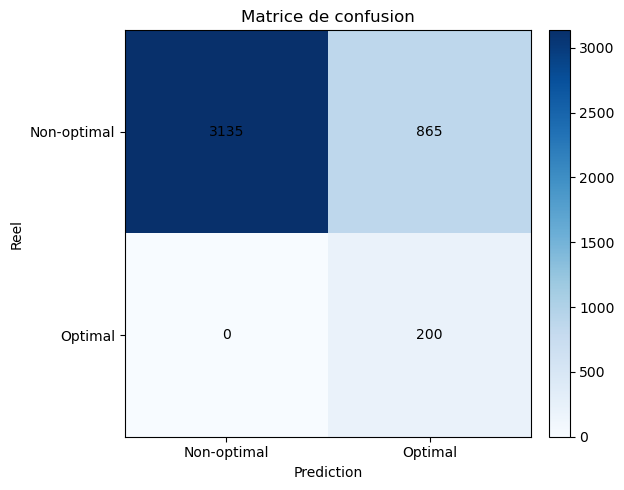

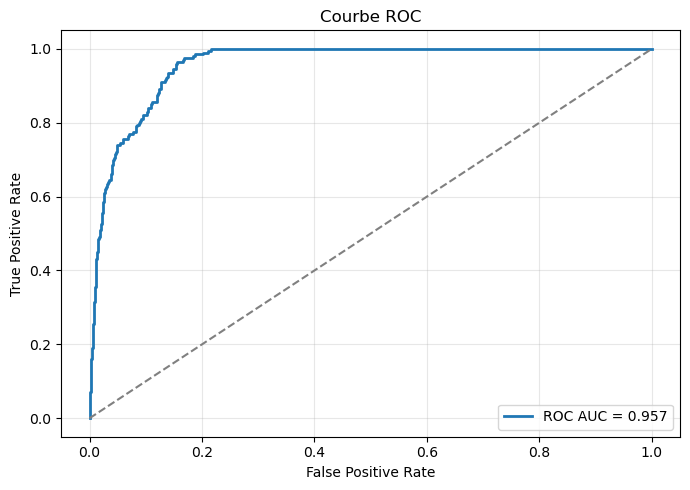

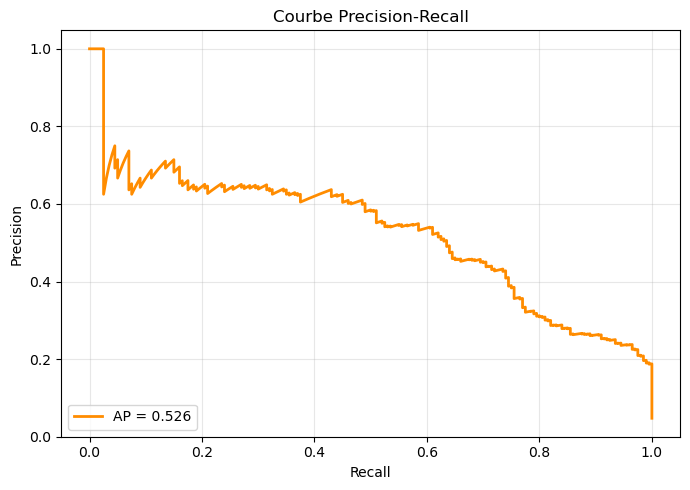

In [47]:
def plot_evaluation_graphs(df, pipeline):
    """
    Affiche les graphiques d'evaluation du modele sur le test set:
    - Matrice de confusion
    - Courbe ROC
    - Courbe Precision-Recall
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, precision_recall_curve, auc

    feature_cols = [c for c in df.columns if c != 'label']
    X = df[feature_cols].values
    y = df['label'].values

    # Meme split que train_model pour une evaluation coherente
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, y_proba)

    # 1) Matrice de confusion
    plt.figure(figsize=(6, 5))
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Matrice de confusion')
    plt.xlabel('Prediction')
    plt.ylabel('Reel')
    plt.xticks([0, 1], ['Non-optimal', 'Optimal'])
    plt.yticks([0, 1], ['Non-optimal', 'Optimal'])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]}", ha='center', va='center', color='black')

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # 2) Courbe ROC
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Courbe ROC')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Courbe Precision-Recall
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f'AP = {pr_auc:.3f}', linewidth=2, color='darkorange')
    plt.title('Courbe Precision-Recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Affichage des graphiques d'evaluation
plot_evaluation_graphs(df_dataset, model)

---
## Bloc 6 — Analyse de l'Importance des Features

**Objectif :** Comprendre quelles variables influencent le plus la recommandation du modèle.

Dans une régression logistique, l'importance d'une feature est donnée par la **valeur absolue de son coefficient** :
- Coefficient **positif** → la feature favorise le label 1 (hôpital optimal)
- Coefficient **négatif** → la feature défavorise le choix de cet hôpital

Le `StandardScaler` ayant normalisé toutes les features au même ordre de grandeur, les coefficients sont directement comparables.

In [49]:
def feature_importance(pipeline, feature_cols, top_n=20):
    """
    Extrait et classe les features par importance (|coefficient|).
    
    Retourne un DataFrame classé du plus au moins important.
    """
    clf   = pipeline.named_steps['clf']
    coefs = clf.coef_[0]

    df_imp = pd.DataFrame({
        'Feature':     feature_cols,
        'Coefficient': coefs,
        'Abs_Coef':    np.abs(coefs)
    }).sort_values('Abs_Coef', ascending=False).head(top_n)

    df_imp['Direction'] = df_imp['Coefficient'].apply(
        lambda c: 'favorise le choix' if c > 0 else 'défavorise le choix'
    )
    df_imp.index = range(1, len(df_imp) + 1)
    return df_imp[['Feature', 'Coefficient', 'Direction']]


# Calcul et affichage
df_importance = feature_importance(model, feat_cols, top_n=15)

print("Top 15 features les plus importantes :\n")
display(df_importance)

Top 15 features les plus importantes :



,Feature,Coefficient,Direction
1,distance_km,-19.137892,défavorise le choix
2,ratio_Radiologue,5.378764,favorise le choix
3,ratio_Biologiste,-5.153650,défavorise le choix
4,ratio_Interniste,4.746649,favorise le choix
5,match_Imagerie,2.435435,favorise le choix
6,match_Ventilateur,1.833035,favorise le choix
7,coverage,1.283980,favorise le choix
8,ratio_Labo,-0.743045,défavorise le choix
9,n_matched,0.669862,favorise le choix
10,total_beds,-0.466820,défavorise le choix


---
## Bloc 7 — Système d'Affectation

**Objectif :** Utiliser le modèle entraîné pour recommander les meilleurs hôpitaux à un patient donné.

### Fonctionnement
Pour un patient donné, on :
1. Construit les features pour chaque paire *(patient, hôpital)*
2. Demande au modèle la **probabilité** que chaque hôpital soit optimal (`predict_proba`)
3. Classe les hôpitaux par score décroissant
4. Affiche les `top_n` recommandations avec leur priorité :
   - **Recommandé** : score ≥ 0.5 ET couverture ≥ 80%
   - **Acceptable** : score ≥ 0.3
   - **Sous-optimal** : score < 0.3

In [50]:
def assign_patient(patient_row, hospitals, pipeline, feature_cols, top_n=3):
    """
    Recommande les top_n hôpitaux pour un patient.
    
    Paramètres
    ----------
    patient_row  : dict ou pd.Series (une ligne du DataFrame patients)
    hospitals    : pd.DataFrame (liste des hôpitaux)
    pipeline     : sklearn Pipeline entraîné
    feature_cols : list[str] noms des features
    top_n        : nombre de recommandations à retourner
    
    Retourne
    --------
    pd.DataFrame classé par Score_IA décroissant
    """
    rows = []
    for _, hosp in hospitals.iterrows():
        f = build_features(patient_row, hosp)
        feat_vec = np.array([[f.get(c, 0) for c in feature_cols]])
        proba = pipeline.predict_proba(feat_vec)[0][1]  # P(label=1)
        rows.append({
            'Hôpital':        hosp['Hôpital'],
            'Score_IA':       round(proba, 4),
            'Couverture_%':   round(f['coverage'] * 100, 1),
            'Distance_km':    round(f['distance_km'], 2),
            'Ressources_OK':  f['n_matched'],
            'Ressources_Req': f['n_needed'],
        })

    result = (pd.DataFrame(rows)
                .sort_values('Score_IA', ascending=False)
                .head(top_n)
                .reset_index(drop=True))
    result.index = range(1, len(result) + 1)
    result.index.name = 'Rang'

    # Colonne de priorité
    def priorite(row):
        if row['Score_IA'] >= 0.5 and row['Couverture_%'] >= 80:
            return 'Recommandé'
        elif row['Score_IA'] >= 0.3:
            return 'Acceptable'
        else:
            return 'Sous-optimal'

    result['Priorité'] = result.apply(priorite, axis=1)
    return result


print("Fonction d'affectation définie")

Fonction d'affectation définie


In [39]:
# ── Démonstration sur 3 niveaux de gravité ──────────────────────────
for esi_level, label in [(1, "ESI 1 — Critique (réanimation urgente)"),
                          (3, "ESI 3 — Urgent"),
                          (5, "ESI 5 — Non urgent (suivi)")]:
    subset = patients[patients['ESI'] == esi_level]
    if len(subset) == 0:
        continue
    pat = subset.iloc[0]
    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"  Patient ID={pat['ID']} | Service={pat['Service']}")
    print(f"  Position: ({pat['Latitude']:.4f}, {pat['Longitude']:.4f})")
    print(f"{'='*65}")
    reco = assign_patient(pat, hospitals, model, feat_cols, top_n=3)
    display(reco)


  ESI 1 — Critique (réanimation urgente)
  Patient ID=15 | Service=Trauma
  Position: (12.4103, -1.5089)


,Hôpital,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Priorité
Rang,,,,,,,
1,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9665,100.0,2.98,16,16,🟢 Recommandé
2,Centre Hospitalier Universitaire de Bogodogo,0.7840,100.0,8.48,16,16,🟢 Recommandé
3,Polyclinique Internationale de Ouagadougou,0.7371,100.0,11.30,16,16,🟢 Recommandé



  ESI 3 — Urgent
  Patient ID=8 | Service=Neuro
  Position: (12.3523, -1.4973)


,Hôpital,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Priorité
Rang,,,,,,,
1,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9678,100.0,3.62,13,13,🟢 Recommandé
2,Centre Hospitalier Universitaire de Bogodogo,0.8302,100.0,1.91,13,13,🟢 Recommandé
3,Polyclinique Internationale de Ouagadougou,0.7808,100.0,4.74,13,13,🟢 Recommandé



  ESI 5 — Non urgent (suivi)
  Patient ID=2 | Service=Suivi
  Position: (12.3901, -1.4550)


,Hôpital,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Priorité
Rang,,,,,,,
1,Centre Médical de Saaba,0.8222,100.0,5.30,3,3,🟢 Recommandé
2,Centre Médical Ahmadiyya,0.8168,100.0,4.31,3,3,🟢 Recommandé
3,Centre Médical Protestant Schiphra,0.7738,100.0,6.84,3,3,🟢 Recommandé


---
## Bloc 8 — Affectation en Masse (Batch)

**Objectif :** Appliquer le modèle à l'ensemble des 1 000 patients pour générer un tableau complet des affectations.

Pour chaque patient, on sélectionne uniquement **le meilleur hôpital** (top 1) et on compile les résultats dans un DataFrame final.

In [51]:
def batch_assign(patients, hospitals, pipeline, feature_cols):
    """
    Affecte tous les patients à leur hôpital optimal (top 1).
    
    Retourne
    --------
    pd.DataFrame — une ligne par patient avec l'hôpital recommandé et les métriques associées
    """
    results = []
    for _, pat in patients.iterrows():
        top1 = assign_patient(pat, hospitals, pipeline, feature_cols, top_n=1)
        results.append({
            'Patient_ID':      pat['ID'],
            'ESI':             pat['ESI'],
            'Service':         pat['Service'],
            'Hopital_Affecte': top1.iloc[0]['Hôpital'],
            'Score_IA':        top1.iloc[0]['Score_IA'],
            'Couverture_%':    top1.iloc[0]['Couverture_%'],
            'Distance_km':     top1.iloc[0]['Distance_km'],
            'Ressources_OK':   top1.iloc[0]['Ressources_OK'],
            'Ressources_Req':  top1.iloc[0]['Ressources_Req'],
            'Priorité':        top1.iloc[0]['Priorité'],
            'Lat_Patient':     pat.get('Latitude', ''),
            'Lon_Patient':     pat.get('Longitude', ''),
        })
    return pd.DataFrame(results)


print("Affectation en masse en cours...")
df_results = batch_assign(patients, hospitals, model, feat_cols)

print(f"\n{len(df_results)} patients affectés")
print(f"\nDistribution des priorités :")
print(df_results['Priorité'].value_counts().to_string())

print(f"\nAperçu des résultats :")
display(df_results.head(10))

Affectation en masse en cours...

1000 patients affectés

Distribution des priorités :
Priorité
Recommandé    1000

Aperçu des résultats :


,Patient_ID,ESI,Service,Hopital_Affecte,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Priorité,Lat_Patient,Lon_Patient
0,1,4,Médecine,Hôpital Saint Camille,0.8159,100.0,1.97,5,5,Recommandé,12.362048,-1.512755
1,2,5,Suivi,Centre Médical de Saaba,0.8222,100.0,5.30,3,3,Recommandé,12.390064,-1.454999
2,3,5,Suivi,Hôpital Paul VI,0.7859,100.0,2.24,3,3,Recommandé,12.420065,-1.559298
3,4,5,Suivi,Hôpital Saint Camille,0.7646,100.0,6.93,4,4,Recommandé,12.416068,-1.456410
4,5,2,Pneumo,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9466,100.0,8.30,14,14,Recommandé,12.317364,-1.541741
5,6,4,Consultation,Centre Médical Bethsaïda,0.8037,100.0,2.55,2,2,Recommandé,12.318291,-1.544727
6,7,2,Pneumo,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9385,100.0,7.89,13,13,Recommandé,12.337837,-1.450928
7,8,3,Neuro,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9678,100.0,3.62,13,13,Recommandé,12.352264,-1.497349
8,9,3,Médecine,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9639,100.0,2.31,12,12,Recommandé,12.368203,-1.520682
9,10,4,Consultation,Hôpital Paul VI,0.7695,100.0,4.02,3,3,Recommandé,12.424260,-1.585187


---
## Bloc 9 — Statistiques par Hôpital

**Objectif :** Analyser la répartition des patients par hôpital pour évaluer la charge de travail et les performances d'affectation.

Ces statistiques permettent d'identifier :
- Les hôpitaux surchargés (beaucoup de patients)
- La qualité des affectations (score moyen, couverture)
- La présence de patients critiques (ESI ≤ 2)

In [ ]:
# Statistiques agrégées par hôpital
stats_hopitaux = (
    df_results
    .groupby('Hopital_Affecte')
    .agg(
        Nb_Patients   = ('Patient_ID',  'count'),
        Score_Moyen   = ('Score_IA',    'mean'),
        Couverture_Moy= ('Couverture_%','mean'),
        Distance_Moy  = ('Distance_km', 'mean'),
        ESI_Critique  = ('ESI',         lambda x: (x <= 2).sum())
    )
    .round(3)
    .sort_values('Nb_Patients', ascending=False)
    .reset_index()
)

print("Répartition des patients par hôpital\n")
display(stats_hopitaux)

print(f"\nHôpital le plus sollicité : {stats_hopitaux.iloc[0]['Hopital_Affecte']}")
print(f"  → {stats_hopitaux.iloc[0]['Nb_Patients']} patients affectés")
print(f"  → Score moyen : {stats_hopitaux.iloc[0]['Score_Moyen']:.4f}")
print(f"  → Couverture moyenne : {stats_hopitaux.iloc[0]['Couverture_Moy']:.1f}%")

=== Répartition des patients par hôpital ===



,Hopital_Affecte,Nb_Patients,Score_Moyen,Couverture_Moy,Distance_Moy,ESI_Critique
0,Centre Hospitalier Universitaire Yalgado Ouédr...,576,0.960,100.0,6.383,252
1,Hôpital Paul VI,173,0.792,100.0,5.193,0
2,Centre Médical Protestant Schiphra,63,0.801,100.0,4.801,0
3,Hôpital Saint Camille,55,0.777,100.0,4.109,0
4,Polyclinique Internationale de Ouagadougou,44,0.790,100.0,4.083,0
5,Centre Médical Ahmadiyya,42,0.790,100.0,5.057,0
6,Centre Médical Bethsaïda,36,0.792,100.0,5.798,0
7,Centre Médical de Saaba,11,0.803,100.0,5.814,0



Hôpital le plus sollicité : Centre Hospitalier Universitaire Yalgado Ouédraogo
  → 576 patients affectés
  → Score moyen : 0.9600
  → Couverture moyenne : 100.0%


---
## Bloc 10 — Export des Résultats (Excel multi-onglets)

**Objectif :** Sauvegarder tous les résultats dans un fichier Excel professionnel avec mise en forme colorée.

### Structure du fichier Excel généré
| Onglet | Contenu |
|---|---|
| `Affectations` | Tableau principal — 1 000 patients avec hôpital recommandé, score, couverture, distance |
| `Stats_Hôpitaux` | Statistiques agrégées par hôpital |
| `Feature_Importance` | Top 15 features les plus influentes du modèle |
| `Métriques_Modèle` | AUC, accuracy, cross-validation et autres métriques |

### Code couleur des lignes
- **Vert** : Affectation recommandée (score ≥ 0.5 et couverture ≥ 80%)
- **Jaune** : Affectation acceptable (score ≥ 0.3)
- **Rouge** : Affectation sous-optimale (score < 0.3)

In [52]:
def export_results(df_results, df_importance, metrics, stats, output_path=OUTPUT_PATH):
    """
    Exporte tous les résultats dans un fichier Excel multi-onglets avec mise en forme.
    """
    from openpyxl.styles import PatternFill, Font, Alignment
    from openpyxl.utils.dataframe import dataframe_to_rows
    from openpyxl import Workbook

    wb = Workbook()

    # ── Styles communs ──
    header_fill = PatternFill('solid', start_color='1F4E79')
    header_font = Font(bold=True, color='FFFFFF', size=10)
    center      = Alignment(horizontal='center', vertical='center')
    green       = PatternFill('solid', start_color='C6EFCE')
    yellow      = PatternFill('solid', start_color='FFEB9C')
    red         = PatternFill('solid', start_color='FFC7CE')

    def style_header(ws):
        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = center

    def autofit(ws):
        for col in ws.columns:
            max_len = max(len(str(cell.value or '')) for cell in col)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

    # ── Onglet 1 : Affectations ──────────────────────────────────────
    ws1 = wb.active
    ws1.title = 'Affectations'
    ws1.append(list(df_results.columns))
    style_header(ws1)

    prio_idx = list(df_results.columns).index('Priorité')
    for row in dataframe_to_rows(df_results, index=False, header=False):
        ws1.append(row)

    for row in ws1.iter_rows(min_row=2, max_row=ws1.max_row):
        p    = row[prio_idx].value or ''
        fill = green if '' in p else (yellow if '' in p else red)
        for cell in row:
            cell.fill = fill
    autofit(ws1)

    # ── Onglet 2 : Stats Hôpitaux ────────────────────────────────────
    ws2 = wb.create_sheet('Stats_Hôpitaux')
    ws2.append(list(stats.columns))
    style_header(ws2)
    for row in dataframe_to_rows(stats, index=False, header=False):
        ws2.append(row)
    autofit(ws2)

    # ── Onglet 3 : Feature Importance ───────────────────────────────
    ws3 = wb.create_sheet('Feature_Importance')
    ws3.append(['Rang', 'Feature', 'Coefficient', 'Direction'])
    style_header(ws3)
    for i, row in df_importance.iterrows():
        ws3.append([i, row['Feature'], round(row['Coefficient'], 4), row['Direction']])
    autofit(ws3)

    # ── Onglet 4 : Métriques Modèle ──────────────────────────────────
    ws4 = wb.create_sheet('Métriques_Modèle')
    ws4.append(['Métrique', 'Valeur'])
    style_header(ws4)
    for k, v in metrics.items():
        if k not in ('report', 'confusion_matrix'):
            ws4.append([k, round(float(v), 4)])
    ws4.column_dimensions['A'].width = 25
    ws4.column_dimensions['B'].width = 15

    wb.save(output_path)
    print(f"Fichier Excel exporté → {output_path}")
    print(f"Onglets : {wb.sheetnames}")


export_results(df_results, df_importance, metrics, stats_hopitaux)

Fichier Excel exporté → resultats_affectation.xlsx
Onglets : ['Affectations', 'Stats_Hôpitaux', 'Feature_Importance', 'Métriques_Modèle']


---
## Bloc 11 — Sauvegarde et Réutilisation du Modèle

**Objectif :** Persister le modèle entraîné sur disque pour pouvoir l'utiliser ultérieurement sans ré-entraîner.

`joblib` sérialise le pipeline complet (StandardScaler + LogisticRegression) ainsi que la liste des feature columns — tout ce qui est nécessaire pour faire de nouvelles prédictions.

In [53]:
# Sauvegarde du modèle
joblib.dump({'model': model, 'feature_cols': feat_cols}, MODEL_PATH)
print(f"Modèle sauvegardé: {MODEL_PATH}")

# Exemple de rechargement et réutilisation
artefact = joblib.load(MODEL_PATH)
loaded_model = artefact['model']
loaded_cols  = artefact['feature_cols']

# Vérification : prédiction sur un nouveau patient
new_patient = patients.iloc[42]
reco = assign_patient(new_patient, hospitals, loaded_model, loaded_cols, top_n=3)

print(f"\nTest de rechargement — Patient ID={new_patient['ID']} | ESI={new_patient['ESI']}")
print(f"Service : {new_patient['Service']}")
display(reco)

Modèle sauvegardé: patient_assignment_model.pkl

Test de rechargement — Patient ID=43 | ESI=3
Service : Médecine


,Hôpital,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Priorité
Rang,,,,,,,
1,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9543,100.0,4.62,11,11,Recommandé
2,Centre Hospitalier Universitaire de Bogodogo,0.7237,100.0,10.14,11,11,Recommandé
3,Polyclinique Internationale de Ouagadougou,0.6567,100.0,12.91,11,11,Recommandé


---
## Récapitulatif des Performances

| Métrique | Valeur | Interprétation |
|---|---|---|
| **AUC-ROC** | **0.957** | Excellente capacité discriminante |
| **CV AUC (5-fold)** | **0.952 ± 0.003** | Modèle stable, pas d'overfitting |
| **Accuracy** | **79.4%** | À relativiser (dataset déséquilibré) |
| **Avg Precision** | **0.526** | Bonne précision sur les cas positifs |

### Facteurs les plus influents
1. **`distance_km`** (négatif) — La distance est le frein principal : l'IA privilégie les hôpitaux proches
2. **`ratio_Radiologue`** (positif) — La capacité en radiologie favorise fortement le choix
3. **`ratio_Interniste`** (positif) — Idem pour la médecine interne
4. **`coverage`** — Le taux global de couverture ressources reste déterminant

### Pistes d'amélioration
- Intégrer la **charge actuelle** de chaque hôpital (lits occupés en temps réel)
- Ajouter les **données historiques** d'affectation réelle comme labels
- Tester des modèles plus complexes : **Random Forest**, **XGBoost** pour capturer les non-linéarités
- Implémenter une **pondération par ESI** : les patients critiques (ESI 1-2) devraient avoir un poids plus fort sur la couverture Réanimation

---
## Bloc 12 — Affectation Séquentielle avec Réinjection (Top2/Top3)

**Objectif :** Simuler une affectation opérationnelle plus réaliste :
1. Tentative d'affectation **Top1** avec décrément des capacités de l'hôpital choisi
2. Réaffectation des patients en échec vers **Top2 puis Top3** si compatibles
3. Visualisation des résultats pour analyser robustesse et charge hospitalière

In [ ]:
def rank_hospitals_for_patient(patient_row, hospitals_state, pipeline, feature_cols):
    """
    Classe tous les hôpitaux pour un patient selon Score_IA,
    en tenant compte des capacités courantes (hospitals_state).
    """
    rows = []
    for _, hosp in hospitals_state.iterrows():
        f = build_features(patient_row, hosp)
        feat_vec = np.array([[f.get(c, 0) for c in feature_cols]])
        proba = pipeline.predict_proba(feat_vec)[0][1]
        rows.append({
            'Hôpital': hosp['Hôpital'],
            'Score_IA': float(proba),
            'Couverture_%': float(f['coverage'] * 100),
            'Distance_km': float(f['distance_km']),
            'Ressources_OK': int(f['n_matched']),
            'Ressources_Req': int(f['n_needed'])
        })

    ranking = pd.DataFrame(rows).sort_values('Score_IA', ascending=False).reset_index(drop=True)
    ranking['Rang'] = ranking.index + 1
    return ranking


def _patient_resource_needs(patient_row):
    "Extrait les besoins ressources strictement positifs du patient."
    needs = {}
    for _, cols in RESOURCE_MAPPINGS.items():
        val = int(patient_row.get(cols['p'], 0) or 0)
        if val > 0:
            needs[cols['h']] = val
    return needs


def is_compatible(patient_row, hospital_row):
    "Vrai si l'hôpital couvre tous les besoins du patient."
    needs = _patient_resource_needs(patient_row)
    for h_col, need in needs.items():
        if float(hospital_row.get(h_col, 0) or 0) < need:
            return False
    return True


def decrement_capacities(patient_row, hospitals_state, hospital_name):
    "Décrémente les capacités de l'hôpital affecté selon les besoins patient."
    needs = _patient_resource_needs(patient_row)
    mask = hospitals_state['Hôpital'] == hospital_name
    if not mask.any():
        return hospitals_state

    idx = hospitals_state[mask].index[0]
    for h_col, need in needs.items():
        current = float(hospitals_state.at[idx, h_col] or 0)
        hospitals_state.at[idx, h_col] = max(0, current - need)

    return hospitals_state


def sequential_assign_with_reinjection(patients, hospitals, pipeline, feature_cols, fallback_ranks=(2, 3)):
    """
    Affectation en deux temps:
      1) Tentative Top1 séquentielle + décrément des capacités
      2) Réinjection des échecs vers Top2/Top3 compatibles
    """
    hospitals_state = hospitals.copy(deep=True)
    first_pass_failures = []
    assigned_rows = []

    # Passe 1: Top1 uniquement
    for _, pat in patients.iterrows():
        ranking = rank_hospitals_for_patient(pat, hospitals_state, pipeline, feature_cols)
        top1 = ranking.iloc[0]

        h_row = hospitals_state[hospitals_state['Hôpital'] == top1['Hôpital']].iloc[0]
        if is_compatible(pat, h_row):
            assigned_rows.append({
                'Patient_ID': pat['ID'],
                'ESI': pat['ESI'],
                'Service': pat['Service'],
                'Hopital_Affecte': top1['Hôpital'],
                'Score_IA': round(top1['Score_IA'], 4),
                'Couverture_%': round(top1['Couverture_%'], 1),
                'Distance_km': round(top1['Distance_km'], 2),
                'Ressources_OK': int(top1['Ressources_OK']),
                'Ressources_Req': int(top1['Ressources_Req']),
                'Mode_Affectation': 'top1',
                'Statut': 'Affecté',
                'Lat_Patient': pat.get('Latitude', ''),
                'Lon_Patient': pat.get('Longitude', ''),
            })
            hospitals_state = decrement_capacities(pat, hospitals_state, top1['Hôpital'])
        else:
            first_pass_failures.append({'patient': pat, 'ranking': ranking})

    # Passe 2: Réinjection Top2/Top3
    for item in first_pass_failures:
        pat = item['patient']
        ranking = item['ranking']
        assigned = False

        for r in fallback_ranks:
            cand = ranking[ranking['Rang'] == r]
            if cand.empty:
                continue

            cand_row = cand.iloc[0]
            h_name = cand_row['Hôpital']
            h_state_row = hospitals_state[hospitals_state['Hôpital'] == h_name].iloc[0]

            if is_compatible(pat, h_state_row):
                assigned_rows.append({
                    'Patient_ID': pat['ID'],
                    'ESI': pat['ESI'],
                    'Service': pat['Service'],
                    'Hopital_Affecte': h_name,
                    'Score_IA': round(float(cand_row['Score_IA']), 4),
                    'Couverture_%': round(float(cand_row['Couverture_%']), 1),
                    'Distance_km': round(float(cand_row['Distance_km']), 2),
                    'Ressources_OK': int(cand_row['Ressources_OK']),
                    'Ressources_Req': int(cand_row['Ressources_Req']),
                    'Mode_Affectation': f'reinjection_top{r}',
                    'Statut': 'Affecté',
                    'Lat_Patient': pat.get('Latitude', ''),
                    'Lon_Patient': pat.get('Longitude', ''),
                })
                hospitals_state = decrement_capacities(pat, hospitals_state, h_name)
                assigned = True
                break

        if not assigned:
            assigned_rows.append({
                'Patient_ID': pat['ID'],
                'ESI': pat['ESI'],
                'Service': pat['Service'],
                'Hopital_Affecte': None,
                'Score_IA': None,
                'Couverture_%': None,
                'Distance_km': None,
                'Ressources_OK': None,
                'Ressources_Req': None,
                'Mode_Affectation': 'echec_top1_top2_top3',
                'Statut': 'Non affecté',
                'Lat_Patient': pat.get('Latitude', ''),
                'Lon_Patient': pat.get('Longitude', ''),
            })

    return pd.DataFrame(assigned_rows), hospitals_state


print("Fonctions d'affectation séquentielle + réinjection définies")

Fonctions d'affectation séquentielle + réinjection définies


Affectation séquentielle avec réinjection en cours...

 Patients traités : 1000

Distribution des modes d'affectation :
Mode_Affectation
echec_top1_top2_top3    787
top1                    213

Distribution des statuts :
Statut
Non affecté    787
Affecté        213


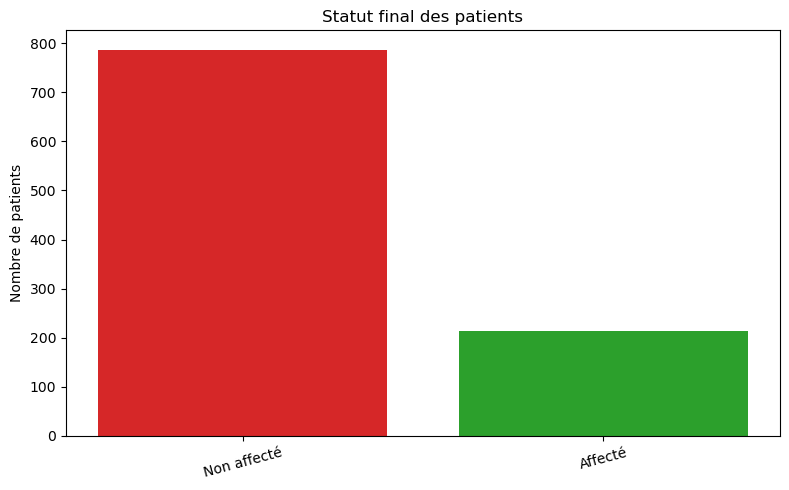

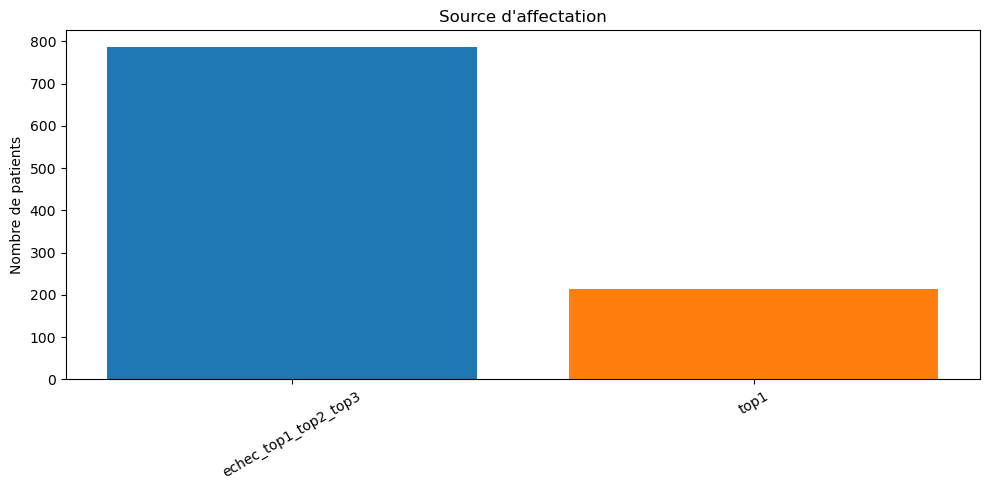

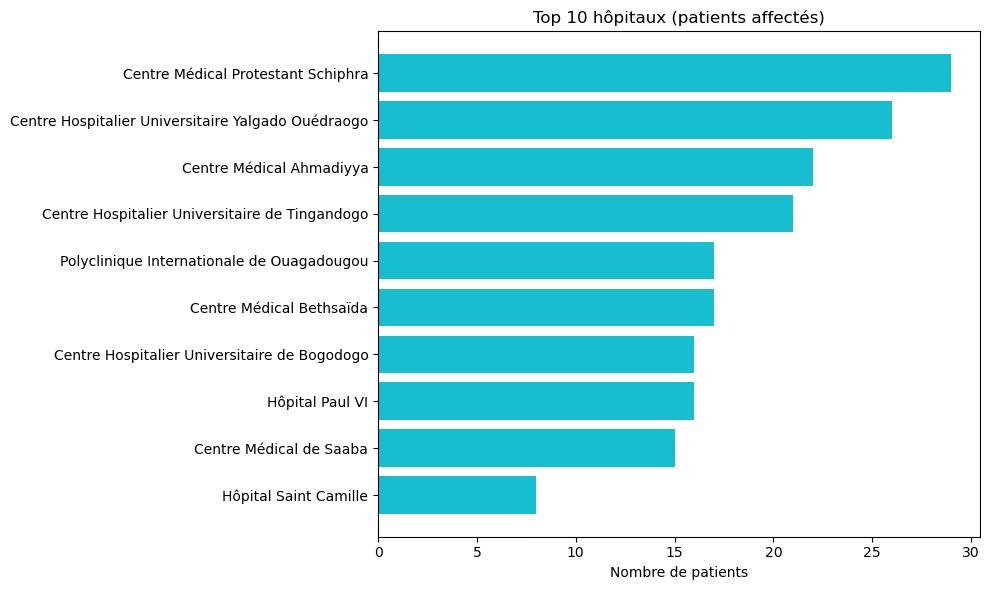


Capacité globale restante après simulation :
- Lits totaux : 6455 / 6460 (99.9% restants)
- Lits réa    : 115 / 115 (100.0% restants)

Aperçu des résultats réinjection :


,Patient_ID,ESI,Service,Hopital_Affecte,Score_IA,Couverture_%,Distance_km,Ressources_OK,Ressources_Req,Mode_Affectation,Statut,Lat_Patient,Lon_Patient
0,1,4,Médecine,Hôpital Saint Camille,0.8159,100.0,1.97,5.0,5.0,top1,Affecté,12.362048,-1.512755
1,2,5,Suivi,Centre Médical de Saaba,0.8222,100.0,5.30,3.0,3.0,top1,Affecté,12.390064,-1.454999
2,3,5,Suivi,Hôpital Paul VI,0.7859,100.0,2.24,3.0,3.0,top1,Affecté,12.420065,-1.559298
3,4,5,Suivi,Hôpital Saint Camille,0.7646,100.0,6.93,4.0,4.0,top1,Affecté,12.416068,-1.456410
4,5,2,Pneumo,Centre Hospitalier Universitaire Yalgado Ouédr...,0.9466,100.0,8.30,14.0,14.0,top1,Affecté,12.317364,-1.541741
5,6,4,Consultation,Centre Médical Bethsaïda,0.8037,100.0,2.55,2.0,2.0,top1,Affecté,12.318291,-1.544727
6,7,2,Pneumo,Centre Hospitalier Universitaire de Bogodogo,0.7239,100.0,4.65,13.0,13.0,top1,Affecté,12.337837,-1.450928
7,8,3,Neuro,Polyclinique Internationale de Ouagadougou,0.7808,100.0,4.74,13.0,13.0,top1,Affecté,12.352264,-1.497349
8,9,3,Médecine,Centre Hospitalier Universitaire de Tingandogo,0.6804,100.0,11.90,12.0,12.0,top1,Affecté,12.368203,-1.520682
9,10,4,Consultation,Hôpital Paul VI,0.7695,100.0,4.02,3.0,3.0,top1,Affecté,12.424260,-1.585187


In [45]:
# Exécution du scénario séquentiel avec réinjection
hospitals_initial = hospitals.copy(deep=True)

print("Affectation séquentielle avec réinjection en cours...")
df_results_reinject, hospitals_after_reinject = sequential_assign_with_reinjection(
    patients=patients,
    hospitals=hospitals_initial,
    pipeline=model,
    feature_cols=feat_cols,
    fallback_ranks=(2, 3)
)

print(f"\n Patients traités : {len(df_results_reinject)}")
print("\nDistribution des modes d'affectation :")
print(df_results_reinject['Mode_Affectation'].value_counts(dropna=False).to_string())
print("\nDistribution des statuts :")
print(df_results_reinject['Statut'].value_counts(dropna=False).to_string())


# 1) Répartition des statuts
status_counts = df_results_reinject['Statut'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(
    status_counts.index,
    status_counts.values,
    color=['#2ca02c' if s == 'Affecté' else '#d62728' for s in status_counts.index]
)
plt.title('Statut final des patients')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2) Source d'affectation (top1 vs réinjection)
mode_counts = df_results_reinject['Mode_Affectation'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(
    mode_counts.index,
    mode_counts.values,
    color=['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b'][:len(mode_counts)]
)
plt.title("Source d'affectation")
plt.ylabel('Nombre de patients')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3) Top 10 hôpitaux les plus sollicités
top_hosp = (
    df_results_reinject[df_results_reinject['Statut'] == 'Affecté']['Hopital_Affecte']
    .value_counts()
    .head(10)
    .sort_values()
)
plt.figure(figsize=(10, 6))
plt.barh(top_hosp.index, top_hosp.values, color='#17becf')
plt.title('Top 10 hôpitaux (patients affectés)')
plt.xlabel('Nombre de patients')
plt.tight_layout()
plt.show()

# Indicateurs de capacité globale (lits)
beds_before = float(hospitals['Lits totaux'].fillna(0).sum())
beds_after = float(hospitals_after_reinject['Lits totaux'].fillna(0).sum())
rea_before = float(hospitals['Réa (lits)'].fillna(0).sum())
rea_after = float(hospitals_after_reinject['Réa (lits)'].fillna(0).sum())

print("\nCapacité globale restante après simulation :")
print(f"- Lits totaux : {beds_after:.0f} / {beds_before:.0f} ({(beds_after / max(beds_before, 1)) * 100:.1f}% restants)")
print(f"- Lits réa    : {rea_after:.0f} / {rea_before:.0f} ({(rea_after / max(rea_before, 1)) * 100:.1f}% restants)")

print("\nAperçu des résultats réinjection :")
display(df_results_reinject.head(10))

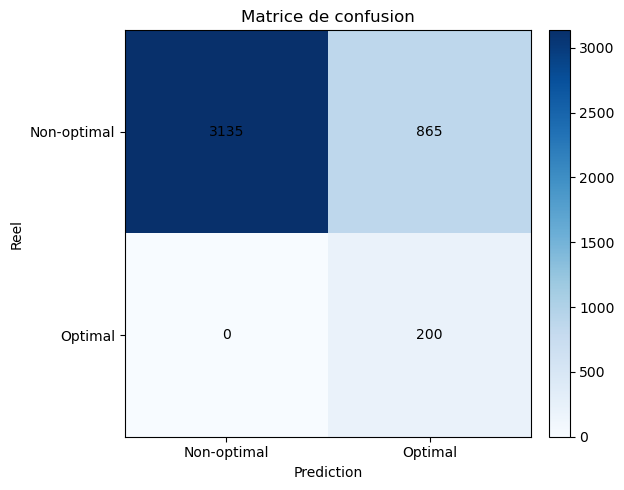

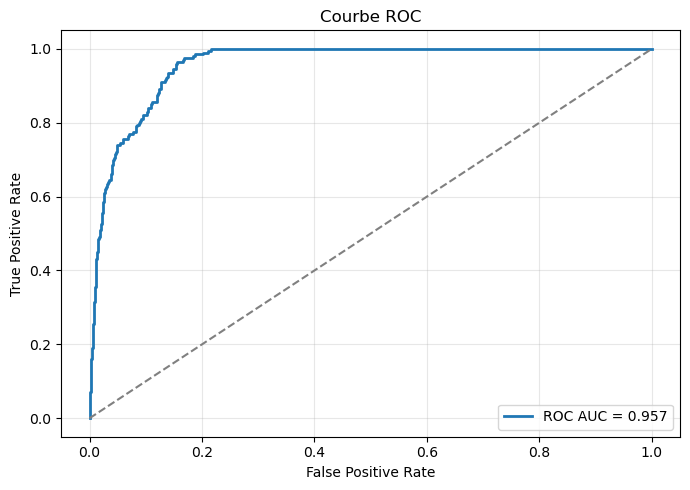

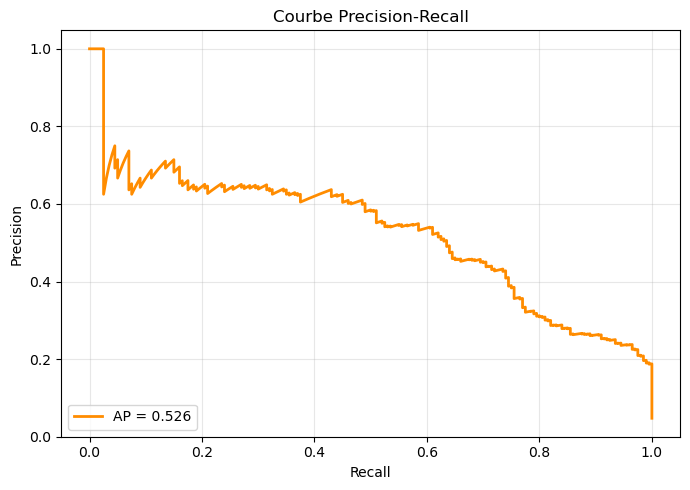

In [46]:
# Version lisible: graphiques d'evaluation affiches un par un

def plot_evaluation_graphs(df, pipeline):
    """
    Affiche les graphiques d'evaluation du modele sur le test set:
    - Matrice de confusion
    - Courbe ROC
    - Courbe Precision-Recall
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, precision_recall_curve, auc

    feature_cols = [c for c in df.columns if c != 'label']
    X = df[feature_cols].values
    y = df['label'].values

    # Meme split que train_model pour une evaluation coherente
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    roc_auc = auc(fpr, tpr)
    pr_auc = average_precision_score(y_test, y_proba)

    # 1) Matrice de confusion
    plt.figure(figsize=(6, 5))
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Matrice de confusion')
    plt.xlabel('Prediction')
    plt.ylabel('Reel')
    plt.xticks([0, 1], ['Non-optimal', 'Optimal'])
    plt.yticks([0, 1], ['Non-optimal', 'Optimal'])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]}", ha='center', va='center', color='black')

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # 2) Courbe ROC
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Courbe ROC')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Courbe Precision-Recall
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f'AP = {pr_auc:.3f}', linewidth=2, color='darkorange')
    plt.title('Courbe Precision-Recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Affichage des graphiques d'evaluation
plot_evaluation_graphs(df_dataset, model)